In [1]:
import os
import pandas as pd
import numpy as np
from lib.uncertinay_rat import SimulateRat
import matplotlib.pyplot as plt

/Users/felix/MSE/03_projects/MT/zz_code/04_experiments/03_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DS_FEVER = '../02_data/2026-03-12/fever'
DS_HOTPOTQA = '../02_data/2026-03-12/hotpotqa'
DS_NQ = '../02_data/2026-03-12/nq'

In [3]:
def get_retrieval_success(row):
    ret_set = set([f"{r['document_id']}:{r['index']}" for r in row['retrieved']])
    ref_set = set([f"{r['document_id']}:{r['index']}" for r in row['reference']])

    return set(ref_set) <= set(ret_set)

def set_abstain(row):
    return (row['generated_answer'] == 'I DO NOT KNOW') or (row['generated_answer'] == 'NOT ENOUGH INFO')

def set_task_success(row):
    return row['correct_answer']

def set_generator_success(row):
    if row['retriever_success'] == True:
        return row['task_success']
    else:
        return row['abstain']

In [4]:
results_all = {}
success_rates = {}
samples_all = {}

simulate = SimulateRat()

for g in os.listdir(f"{DS_FEVER}"):
    for experiment in os.listdir(f"{DS_FEVER}/{g}/"):
        id = experiment.split('_')
        results = pd.read_json(f'{DS_FEVER}/{g}/{experiment}/results.json')

        results['dataset'] = 'fever'
        results['generator'] = g
        results['retriever_strategy'] = experiment

        results['correct_query'] = True
        results['retriever_success'] = results.apply(get_retrieval_success, axis=1)
        results['abstain'] = results.apply(set_abstain, axis=1)
        results['task_success'] = results.apply(set_task_success, axis=1)
        results['generator_success'] = results.apply(set_generator_success, axis=1)

        results_all[f"fever_{g}_{experiment}"] = results
        success_rates[f"fever_{g}_{experiment}"], samples_all[f"fever_{g}_{experiment}"] = simulate.compute_uncertainty(results)


for g in os.listdir(f"{DS_HOTPOTQA}"):
    for experiment in os.listdir(f"{DS_HOTPOTQA}/{g}/"):
        id = experiment.split('_')
        results = pd.read_json(f'{DS_HOTPOTQA}/{g}/{experiment}/results.json')

        results['dataset'] = 'hotpotqa'
        results['generator'] = g
        results['retriever_strategy'] = experiment

        results['correct_query'] = True
        results['retriever_success'] = results.apply(get_retrieval_success, axis=1)
        results['abstain'] = results.apply(set_abstain, axis=1)
        results['task_success'] = results.apply(set_task_success, axis=1)
        results['generator_success'] = results.apply(set_generator_success, axis=1)
                            
        results_all[f"hotpotqa_{g}_{experiment}"] = results
        success_rates[f"hotpotqa_{g}_{experiment}"], samples_all[f"hotpotqa_{g}_{experiment}"] = simulate.compute_uncertainty(results)

for g in os.listdir(f"{DS_NQ}"):
    for experiment in os.listdir(f"{DS_NQ}/{g}/"):
        try:
            id = experiment.split('_')
            results = pd.read_json(f'{DS_NQ}/{g}/{experiment}/results.json')

            results['dataset'] = 'nq'
            results['generator'] = g
            results['retriever_strategy'] = experiment

            results['correct_query'] = True
            results['retriever_success'] = results.apply(get_retrieval_success, axis=1)
            results['abstain'] = results.apply(set_abstain, axis=1)
            results['task_success'] = results.apply(set_task_success, axis=1)
            results['generator_success'] = results.apply(set_generator_success, axis=1)
                                
            results_all[f"nq_{g}_{experiment}"] = results
            success_rates[f"nq_{g}_{experiment}"], samples_all[f"nq_{g}_{experiment}"] = simulate.compute_uncertainty(results)
        except:
            continue

out = pd.concat((df for df in results_all.values()), ignore_index=True)


In [5]:
def compute_f(samples, x_obs):
    t_r1 = samples['t_r1_a1'] * samples['a_r1'] + samples['t_r1_a0'] * (1 - samples['a_r1'])
    t_r0 = samples['t_r0_a1'] * samples['a_r0'] + samples['t_r0_a0'] * (1 - samples['a_r0'])

    f_samples = (t_r1 - t_r0)[:, None] * x_obs[None, :] + t_r0[:, None]

    p5  = np.percentile(f_samples, 5,  axis=0)
    p25 = np.percentile(f_samples, 25, axis=0)
    p75 = np.percentile(f_samples, 75, axis=0)
    p95 = np.percentile(f_samples, 95, axis=0)

    return {
        'mean': f_samples.mean(axis=0),
        'std': f_samples.std(axis=0),
        'p5': p5,
        'p25': p25,
        'p75': p75,
        'p95': p95,
    }

In [6]:
def plot_base(df, key, ax, show_estimates=True):
    x_obs = np.arange(0, 1.01, 0.1)
    df = df[key]
    f = compute_f(samples_all[key], x_obs)

    ax.plot(
        df['retriever_success'].mean(),
        df['task_success'].mean(),
        marker='x',
        label=key.split('_')[-1].capitalize(),
    )

    if show_estimates == True:
        color = plt.gca().lines[-1].get_color()

        ax.fill_between(x_obs, f['p5'], f['p95'], color=color, alpha=0.15)
        ax.fill_between(x_obs, f['p25'], f['p75'], color=color, alpha=0.30)
        ax.plot(x_obs, f['mean'], color=color)

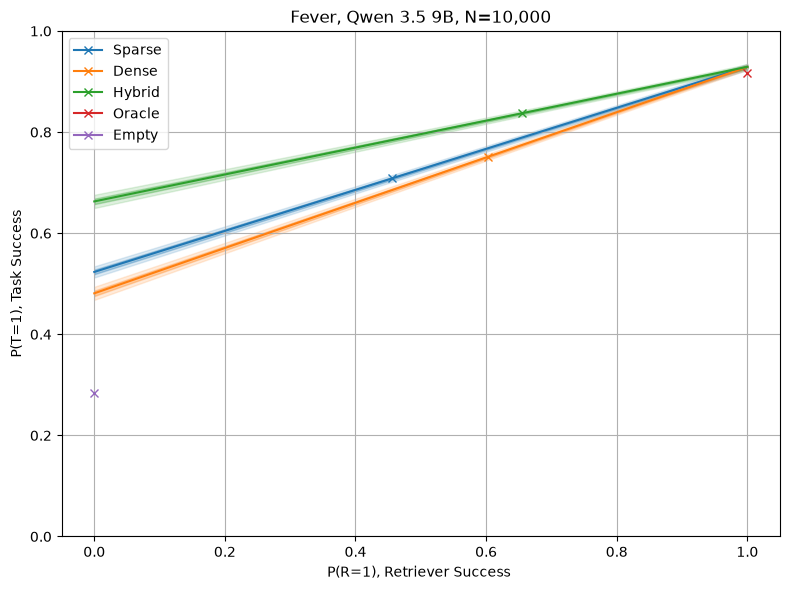

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_base(results_all, 'fever_qwen_sparse', ax)
plot_base(results_all, 'fever_qwen_dense', ax)
plot_base(results_all, 'fever_qwen_hybrid', ax)
plot_base(results_all, 'fever_qwen_oracle', ax, False)
plot_base(results_all, 'fever_qwen_empty', ax, False)

plt.xlabel("P(R=1), Retriever Success ")
plt.ylabel("P(T=1), Task Success")
plt.title("Fever, Qwen 3.5 9B, N=10,000")

plt.xlim(-0.05,1.05)
plt.ylim(0, 1)

plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


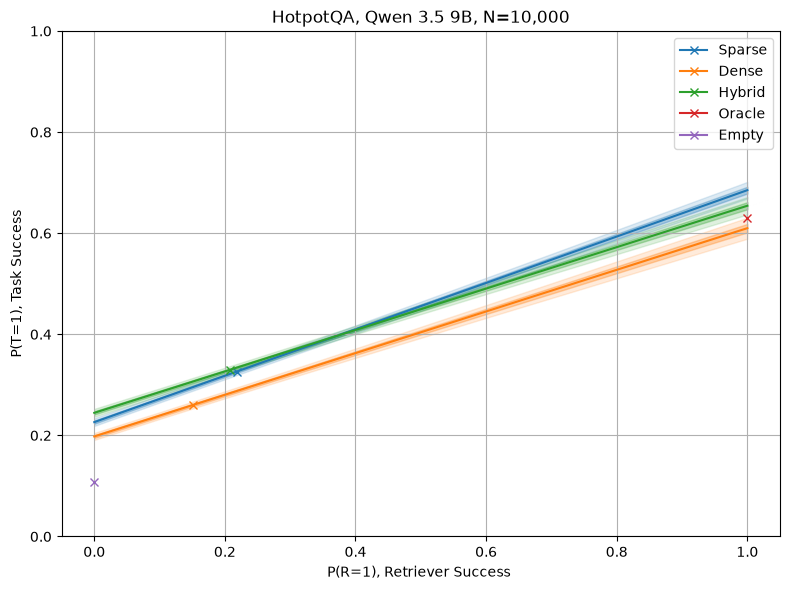

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_base(results_all, 'hotpotqa_qwen_sparse', ax)
plot_base(results_all, 'hotpotqa_qwen_dense', ax)
plot_base(results_all, 'hotpotqa_qwen_hybrid', ax)
plot_base(results_all, 'hotpotqa_qwen_oracle', ax, False)
plot_base(results_all, 'hotpotqa_qwen_empty', ax, False)

plt.xlabel("P(R=1), Retriever Success ")
plt.ylabel("P(T=1), Task Success")
plt.title("HotpotQA, Qwen 3.5 9B, N=10,000")

plt.xlim(-0.05,1.05)
plt.ylim(0, 1)

plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


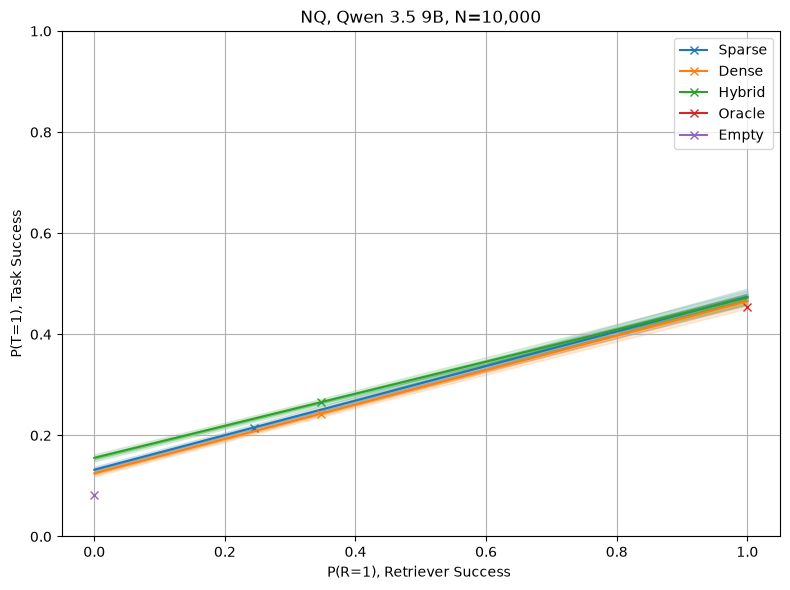

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_base(results_all, 'nq_qwen_sparse', ax)
plot_base(results_all, 'nq_qwen_dense', ax)
plot_base(results_all, 'nq_qwen_hybrid', ax)
plot_base(results_all, 'nq_qwen_oracle', ax, False)
plot_base(results_all, 'nq_qwen_empty', ax, False)

plt.xlabel("P(R=1), Retriever Success ")
plt.ylabel("P(T=1), Task Success")
plt.title("NQ, Qwen 3.5 9B, N=10,000")

plt.xlim(-0.05,1.05)
plt.ylim(0, 1)

plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()
